In [6]:
!pip install networkx numpy matplotlib scipy

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.1 MB 1.1 MB/s eta 0:00:02
   -------------------- ------------------- 1.0/2.1 MB 1.8 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 2.7 MB/s  0:00:01



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [97]:
import time
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [98]:
def translate_in_list(G, n_left, n_right):
    g = [[] for _ in range(n_left)]
    for v in range(n_left):
        for u in G.neighbors(v):
            if u >= n_left:
                g[v].append(u - n_left)
    return g

In [99]:
def kuhn_matching(g, left_v, right_v):
    match = [-1] * right_v
    used = [0] * left_v

    def obhod_v_glubinu(v):
        if used[v] == 1:
            return False
        used[v] = 1

        for kuda_idem in g[v]:
            if match[kuda_idem] == -1 or obhod_v_glubinu(match[kuda_idem]):
                match[kuda_idem] = v
                return True

        return False

    for v in range(left_v):
        used = [0] * left_v
        obhod_v_glubinu(v)

    pairs = []
    for y in range(right_v):
        if match[y] != -1:
            pairs.append((match[y], y))

    return pairs

In [100]:
times = []
G = nx.bipartite.random_graph(1000, 1000, 0.001)
g = translate_in_list(G, 1000, 1000)
for i in range(100):
    start = time.perf_counter()
    pairs = kuhn_matching(g, 1000, 1000)
    end = time.perf_counter()
    times.append(end-start)
print(times)

[0.0034429000224918127, 0.004726999963168055, 0.003331499989144504, 0.004703600017819554, 0.0037613000022247434, 0.0034856999991461635, 0.003614799992647022, 0.0031683999695815146, 0.0028046999941579998, 0.003332399995997548, 0.0030743000097572803, 0.0030139999580569565, 0.0030886000022292137, 0.002915700024459511, 0.0029786000377498567, 0.0026621000142768025, 0.0028879999881610274, 0.002813300001434982, 0.0029634999809786677, 0.0030202000052668154, 0.003368699981365353, 0.002873399993404746, 0.002796799992211163, 0.002820699999574572, 0.0029633999802172184, 0.0028374000103212893, 0.0030205000075511634, 0.002814000006765127, 0.002816900028847158, 0.0030606999644078314, 0.0028768000192940235, 0.0028326999745331705, 0.0028623000252991915, 0.0028525000088848174, 0.0035198000259697437, 0.002884899964556098, 0.002932499977760017, 0.00313660001847893, 0.002915100019890815, 0.002800899965222925, 0.0026222000014968216, 0.002701799967326224, 0.002821300004143268, 0.0028716999804601073, 0.002945

In [101]:
times = np.array(times)
times.mean(), times.std()

(np.float64(0.0029898439982207494), np.float64(0.00033249934837735614))

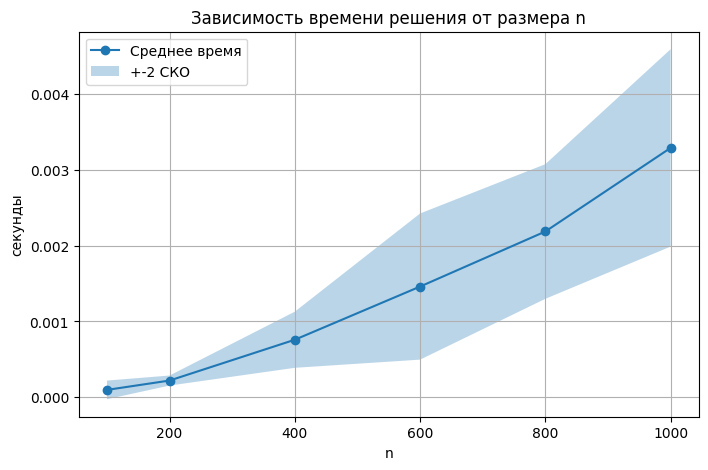

In [102]:
ns = [100, 200, 400, 600, 800, 1000]
means = []
stds = []
for n in ns:
    times = []
    for _ in range(100):
        G = nx.bipartite.random_graph(n, n, 0.001)
        g = translate_in_list(G, n, n)
        start = time.perf_counter()
        kuhn_matching(g, n, n)
        end = time.perf_counter()
        times.append(end - start)
    times = np.array(times)
    means.append(times.mean())
    stds.append(times.std())

means = np.array(means)
stds = np.array(stds)

plt.figure(figsize=(8, 5))
plt.plot(ns, means, marker='o', label='Среднее время')
plt.fill_between(ns, means - 2 * stds, means + 2 * stds, alpha=0.3, label='+-2 СКО')
plt.xlabel('n')
plt.ylabel('секунды')
plt.title('Зависимость времени решения от размера n')
plt.grid(True)
plt.legend()
plt.show()

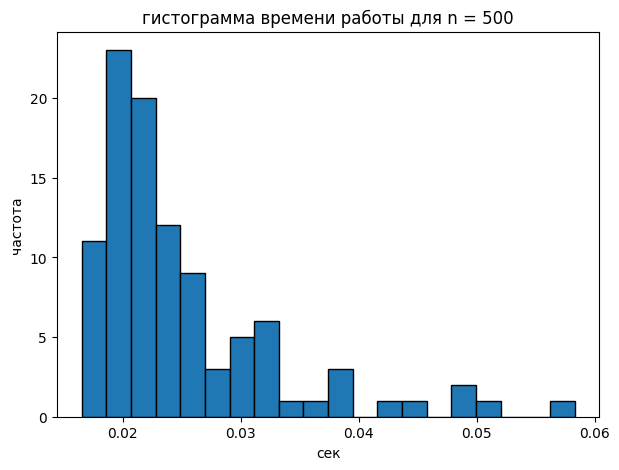

In [103]:
n = 500
times = []

for _ in range(100):
    G = nx.bipartite.random_graph(n, n, 0.01)
    g = translate_in_list(G, n, n)
    start = time.perf_counter()
    kuhn_matching(g, n, n)
    end = time.perf_counter()
    times.append(end - start)

plt.figure(figsize=(7,5))
plt.hist(times, bins=20, edgecolor='black')
plt.xlabel("сек")
plt.ylabel("частота")
plt.title(f"гистограмма времени работы для n = 500")
plt.show()

In [104]:
times = np.array(times)

mu = times.mean()
sigma = times.std()

_, p_value = stats.kstest(times, 'norm', args=(mu, sigma))

print("Среднее:", mu)
print("СКО:", sigma)
print("p-value:", p_value)

if p_value > 0.05:
    print("гипотеза не отвергается")
else:
    print("гипотеза отвергается")

Среднее: 0.02503349599952344
СКО: 0.007832093516218682
p-value: 0.0005064751289310055
гипотеза отвергается
